# Presentation boards

Boards for the talk, organized by section. Each render cell saves a PNG to `TALK_DIR` (default `notebooks/talk_boards/`) so slides can pull them directly.

In [44]:
import os, sys, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from board_style import draw_board
from data.othello import OthelloBoardState

%matplotlib inline

# Where PNGs land.  Created on demand.
TALK_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'talk_boards')
os.makedirs(TALK_DIR, exist_ok=True)

HIGHLIGHT_COLOR = 'orange'
OUTLINE_LW = 4.0


def render_board(state, highlight_cells, out_name, title=None,
                    figsize=(5, 5), show_coords=True, save=True):
    """Render an 8x8 board with the given cells outlined in orange.

    state:            (8, 8) numpy array, values in {-1, 0, 1}.
    highlight_cells:  iterable of (row, col) tuples to outline.
    out_name:         PNG filename (saved under TALK_DIR when save=True).
    """
    highlights = {
        (r, c): {'border': HIGHLIGHT_COLOR, 'border_lw': OUTLINE_LW}
        for r, c in highlight_cells
    }
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    draw_board(ax, state, highlights=highlights, title=title,
                show_coords=show_coords)
    plt.tight_layout()
    if save:
        out_path = os.path.join(TALK_DIR, out_name)
        plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
        print(f'  saved {out_path}')
    plt.show()

## Section 1 — First four moves of a game

Each move gets two slides:
- **A**: the new piece is placed (orange outline marks it).
- **B**: all opponent pieces that get flipped by that move are shown flipped, with orange outlines.

In [ ]:
# Play 4 moves and capture per-move snapshots.  Seed for reproducibility.
SEED = 0
N_MOVES = 4

rng = random.Random(SEED)
board = OthelloBoardState()

snapshots = []
for i in range(N_MOVES):
    valid = board.get_valid_moves()
    if not valid:
        board.update([])
        valid = board.get_valid_moves()
        if not valid:
            break
    move = rng.choice(valid)
    r, c = move // 8, move % 8
    state_before = np.asarray(board.state, dtype=np.int8).reshape(8, 8).copy()
    board.update([move])
    state_after = np.asarray(board.state, dtype=np.int8).reshape(8, 8).copy()

    mover_color = int(state_after[r, c])   # +1 black / -1 white
    state_placed = state_before.copy()
    state_placed[r, c] = mover_color

    flipped = [(rr, cc) for rr in range(8) for cc in range(8)
                if (rr, cc) != (r, c)
                and state_before[rr, cc] != state_after[rr, cc]]

    snapshots.append({
        'move_idx': i + 1,
        'cell': (r, c),
        'mover': 'black' if mover_color == 1 else 'white',
        'state_placed': state_placed,
        'state_after': state_after,
        'flipped': flipped,
    })

for s in snapshots:
    print(f"Move {s['move_idx']}: {s['mover']} plays ({s['cell'][0]}, {s['cell'][1]}); "
          f"flips {len(s['flipped'])} piece(s) at {s['flipped']}")

In [ ]:
# Move 1A — piece placed, no flips yet
s = snapshots[0]
render_board(s['state_placed'],
             highlight_cells=[s['cell']],
             out_name=f"move{s['move_idx']}a_place.png",
             title=f"Move {s['move_idx']}: {s['mover']} places at ({s['cell'][0]}, {s['cell'][1]})")

In [ ]:
# Move 1B — flips resolved, flipped cells outlined
s = snapshots[0]
render_board(s['state_after'],
             highlight_cells=s['flipped'],
             out_name=f"move{s['move_idx']}b_flip.png",
             title=f"Move {s['move_idx']} flips: {len(s['flipped'])} piece(s)")

In [ ]:
# Move 2A
s = snapshots[1]
render_board(s['state_placed'],
             highlight_cells=[s['cell']],
             out_name=f"move{s['move_idx']}a_place.png",
             title=f"Move {s['move_idx']}: {s['mover']} places at ({s['cell'][0]}, {s['cell'][1]})")

In [ ]:
# Move 2B
s = snapshots[1]
render_board(s['state_after'],
             highlight_cells=s['flipped'],
             out_name=f"move{s['move_idx']}b_flip.png",
             title=f"Move {s['move_idx']} flips: {len(s['flipped'])} piece(s)")

In [ ]:
# Move 3A
s = snapshots[2]
render_board(s['state_placed'],
             highlight_cells=[s['cell']],
             out_name=f"move{s['move_idx']}a_place.png",
             title=f"Move {s['move_idx']}: {s['mover']} places at ({s['cell'][0]}, {s['cell'][1]})")

In [ ]:
# Move 3B
s = snapshots[2]
render_board(s['state_after'],
             highlight_cells=s['flipped'],
             out_name=f"move{s['move_idx']}b_flip.png",
             title=f"Move {s['move_idx']} flips: {len(s['flipped'])} piece(s)")

In [ ]:
# Move 4A
s = snapshots[3]
render_board(s['state_placed'],
             highlight_cells=[s['cell']],
             out_name=f"move{s['move_idx']}a_place.png",
             title=f"Move {s['move_idx']}: {s['mover']} places at ({s['cell'][0]}, {s['cell'][1]})")

In [ ]:
# Move 4B
s = snapshots[3]
render_board(s['state_after'],
             highlight_cells=s['flipped'],
             out_name=f"move{s['move_idx']}b_flip.png",
             title=f"Move {s['move_idx']} flips: {len(s['flipped'])} piece(s)")

## Section 2 — Architecture diagrams

Three minimalist black-and-white diagrams: Othello-GPT, the trained MLP, and the hand-crafted MLP.  '1980s computer' aesthetic — sharp rectangles, straight arrows, monospace text, no fills.

In [ ]:
MONO = {'family': 'monospace'}


def arch_box(ax, cx, cy, w, h, label, fontsize=11, lw=1.6):
    """Sharp-cornered rectangle with centered monospace text."""
    ax.add_patch(mpatches.Rectangle(
        (cx - w / 2, cy - h / 2), w, h,
        facecolor='white', edgecolor='black', linewidth=lw))
    ax.text(cx, cy, label, ha='center', va='center',
             fontsize=fontsize, fontdict=MONO, color='black')


def arch_arrow(ax, x0, y0, x1, y1, lw=1.3):
    """Straight arrow, sharp arrowhead."""
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                 arrowprops=dict(arrowstyle='-|>', linewidth=lw,
                                  color='black', mutation_scale=12))


def render_arch(build_fn, out_name, figsize):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    ax.set_aspect('equal')
    ax.axis('off')
    build_fn(ax)
    plt.tight_layout()
    out_path = os.path.join(TALK_DIR, out_name)
    plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f'  saved {out_path}')
    plt.show()

In [ ]:
# Othello-GPT: input -> 8 transformer layers (attention + MLP) -> output
def build_ogpt(ax):
    ax.set_xlim(0, 6.0)
    ax.set_ylim(0, 12.0)

    cx = 3.0
    box_w = 3.4
    box_h = 0.65

    # Header label (matches the 'Trained'/'Handcrafted' style below)
    ax.text(cx, 11.55, 'Othello-GPT (Trained)', ha='center', va='center',
             fontsize=13, fontdict=MONO, color='black', fontweight='bold')

    arch_box(ax, cx, 10.85, box_w, box_h, 'Move history')
    arch_box(ax, cx, 10.05, box_w, box_h, 'Move embedding')
    arch_arrow(ax, cx, 10.85 - box_h/2, cx, 10.05 + box_h/2)

    # 8 transformer layers, each Attention + MLP (side by side).  No
    # outer rectangle; layer label sits ABOVE the two inner boxes.
    layer_top = 9.25
    layer_h = 0.65
    layer_gap = 0.25
    attn_cx = 1.7
    mlp_cx = 4.3
    inner_w = 2.35
    inner_h = 0.55

    for i in range(8):
        cy = layer_top - i * (layer_h + layer_gap) - layer_h / 2
        # Layer label above the inner boxes.
        ax.text(0.45, cy - 0.05 + inner_h / 2 + 0.03, f'Layer {i}',
                 ha='left', va='bottom', fontsize=8, fontdict=MONO)
        arch_box(ax, attn_cx, cy - 0.05, inner_w, inner_h,
                  'Attention', fontsize=9, lw=1.2)
        arch_box(ax, mlp_cx, cy - 0.05, inner_w, inner_h,
                  'MLP (H=512)', fontsize=9, lw=1.2)
        # arrow from previous layer / embedding into this layer
        prev_bottom = (10.05 - box_h / 2) if i == 0 else (
            layer_top - (i - 1) * (layer_h + layer_gap) - layer_h)
        arch_arrow(ax, cx, prev_bottom, cx, cy - 0.05 + inner_h / 2)

    last_bottom = layer_top - (7) * (layer_h + layer_gap) - layer_h
    arch_box(ax, cx, last_bottom - 0.55, box_w, box_h, 'Output (next move)')
    arch_arrow(ax, cx, last_bottom, cx, last_bottom - 0.55 + box_h/2)


render_arch(build_ogpt, 'arch_ogpt.png', figsize=(4.8, 10.5))

In [ ]:
# Trained MLP: Input (60 x 2) -> Hidden (H=512) -> Output (960)
def build_mlp_trained(ax):
    ax.set_xlim(0, 5.0)
    ax.set_ylim(0, 6.5)

    cx = 2.5
    box_w = 3.4
    box_h = 0.75

    ax.text(cx, 6.1, 'MLP (Trained)', ha='center', va='center',
             fontsize=13, fontdict=MONO, color='black', fontweight='bold')

    arch_box(ax, cx, 5.25, box_w, box_h, 'Input  (60 x 2)')
    arch_box(ax, cx, 3.55, box_w, box_h, 'Hidden (H = 512)')
    arch_box(ax, cx, 1.85, box_w, box_h, 'Output (960)')

    arch_arrow(ax, cx, 5.25 - box_h/2, cx, 3.55 + box_h/2)
    arch_arrow(ax, cx, 3.55 - box_h/2, cx, 1.85 + box_h/2)


render_arch(build_mlp_trained, 'arch_mlp_trained.png', figsize=(4.6, 5.4))

In [ ]:
# Hand-crafted MLP: Input (60 x 2) -> Hidden (~3500 leaves) -> Output (960)
def build_mlp_handcrafted(ax):
    ax.set_xlim(0, 5.0)
    ax.set_ylim(0, 6.5)

    cx = 2.5
    box_w = 3.4
    box_h = 0.75

    ax.text(cx, 6.1, 'MLP (Handcrafted)', ha='center', va='center',
             fontsize=13, fontdict=MONO, color='black', fontweight='bold')

    arch_box(ax, cx, 5.25, box_w, box_h, 'Input  (60 x 2)')
    arch_box(ax, cx, 3.55, box_w, box_h, 'Hidden (H ~ 3500)')
    arch_box(ax, cx, 1.85, box_w, box_h, 'Output (960)')

    arch_arrow(ax, cx, 5.25 - box_h/2, cx, 3.55 + box_h/2)
    arch_arrow(ax, cx, 3.55 - box_h/2, cx, 1.85 + box_h/2)


render_arch(build_mlp_handcrafted, 'arch_mlp_handcrafted.png', figsize=(4.6, 5.4))

## Section 3 — Performance figures

**Data + model loading** (needed for the boards below).  We use the adversarial records in `experiment1_by_depth/adversarial_records.npz` plus the trained MLP checkpoint to compute per-cell probabilities on the fly.

This section is scaffolding — pick a model, load once, then render three groups of boards:
1. **Adversarial position**: every cell with p > 1% outlined, p printed inside.
2. **Adversarial game triptych**: the position at t\_L (last legal same-parity turn), t\_I (illegal move chosen), and t\_I + 1 (or +2, next same-parity turn).
3. **No-flanker-but-p-grows example**: search regular games for a position where p(cell) increases as an opponent-piece line grows in one direction, even though the flanking terminal is missing.

In [45]:
# Hardcoded game data for Section 3 boards.
# Games + metadata are visible/editable here.  Probs come from the
# pre-computed npz at notebooks/talk_data/performance_data.npz (row k
# of top_probs matches ADV_GAMES[k]).
#
# The npz is produced on the cluster by:
#   python notebooks/prep_performance_data.py --adv-search-k 300

PERF_PATH = os.path.join(REPO_ROOT, 'notebooks/talk_data/performance_data.npz')
perf = np.load(PERF_PATH, allow_pickle=True)

ADV_GAMES = [
    {
        'label': '#1  adv[13]',
        'game': [37, 45, 19, 34, 41, 33, 42, 48, 26, 38, 54, 43, 40, 25, 49,
                 57, 58, 10, 20, 51, 12, 21, 17, 9, 1, 18, 56, 63, 50, 11, 2,
                 3, 4],
        't_L': 22, 't_transition': 24, 'T': 32, 'C': 24,
        'P_L': 0.0615, 'P_I': 0.2247,
    },
    {
        'label': '#2  adv[4]',
        'game': [19, 18, 17, 9, 44, 16, 0, 1, 2, 45, 25, 34, 33, 43, 52, 20,
                 11, 59, 54],
        't_L': 14, 't_transition': 16, 'T': 18, 'C': 37,
        'P_L': 0.1045, 'P_I': 0.2138,
    },
    {
        'label': '#3  adv[271]',
        'game': [19, 20, 37, 44, 45, 30, 43, 51, 59, 53, 38, 34, 46, 52, 33,
                 39, 55, 29, 31, 54, 62, 60, 13, 23],
        't_L': 17, 't_transition': 19, 'T': 23, 'C': 42,
        'P_L': 0.0998, 'P_I': 0.2075,
    },
    {
        'label': '#4  adv[146]',
        'game': [37, 43, 26, 21, 29, 45, 14, 7, 20, 19, 30, 38, 13, 12, 18,
                 17, 22, 31, 4],
        't_L': 16, 't_transition': 18, 'T': 18, 'C': 44,
        'P_L': 0.2009, 'P_I': 0.2826,
    },
    {
        'label': '#5  adv[2]',
        'game': [19, 18, 17, 9, 44, 16, 0, 1, 2, 45, 25, 34, 33, 43, 52, 20,
                 11, 59, 13],
        't_L': 14, 't_transition': 16, 'T': 18, 'C': 37,
        'P_L': 0.1045, 'P_I': 0.2004,
    },
]

# For the no-flanker figure: the single winning position (line_len=6) and
# the (short) line-growth sequence found in that game (lengths 1..3).
NOFLANK = {
    'target_cell': (3, 5),          # row, col
    'direction': (1, 0),            # down (dr, dc)
}


def state_after_replay(game, turn):
    """Replay `game[0..turn]` (i.e., turn+1 moves) and return (8, 8) state.
    Matches state_at_turn convention in the prep script."""
    board = OthelloBoardState()
    for m in game[:turn + 1]:
        board.umpire(int(m))
    return np.asarray(board.state, dtype=np.int8).reshape(8, 8).copy()


def render_probs_board(state, probs, focus_cell, legal, out_name,
                          title=None, min_p=0.01, figsize=(5.5, 5.5)):
    """Board with cells > min_p labeled, focus cell outlined green/red."""
    highlights = {}
    for r in range(8):
        for c in range(8):
            if state[r, c] != 0:
                continue
            p = float(probs[r, c])
            spec = {}
            if p > min_p:
                spec['label'] = f'{100*p:.0f}%'
            if (r, c) == tuple(focus_cell):
                spec['border'] = 'green' if legal else 'red'
                spec['border_lw'] = 4.0
            if spec:
                highlights[(r, c)] = spec
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    draw_board(ax, state, highlights=highlights, title=title,
                show_coords=True, fontsize=8)
    plt.tight_layout()
    out_path = os.path.join(TALK_DIR, out_name)
    plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f'  saved {out_path}')
    plt.show()


print(f'ADV_GAMES: {len(ADV_GAMES)} adversarial records hardcoded')
print(f'perf npz has top_probs shape {perf["top_probs"].shape}')

ADV_GAMES: 5 adversarial records hardcoded
perf npz has top_probs shape (5, 3, 8, 8)



=== #1  adv[13]: C=24 at (3, 0)   P_L=0.061  P_I=0.225  retention=3.65
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv1_moment1.png


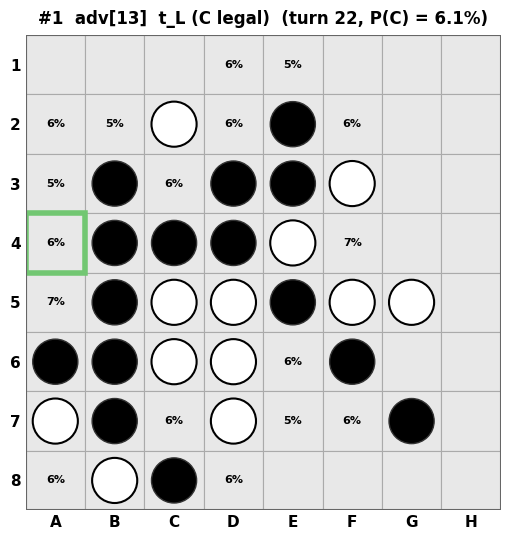

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv1_moment2.png


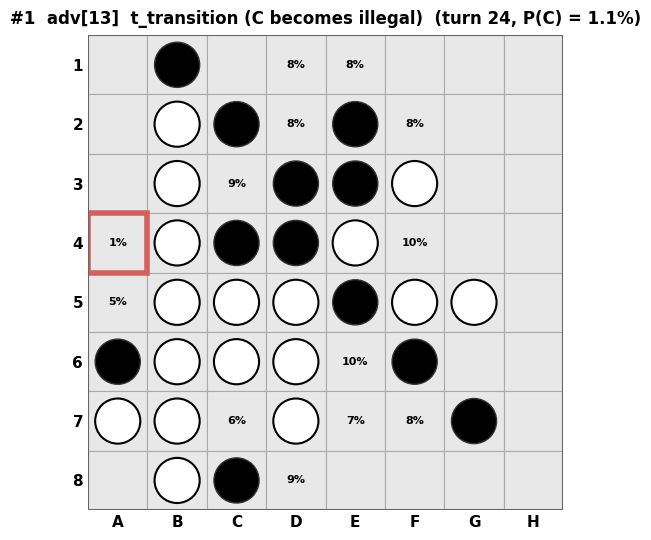

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv1_moment3.png


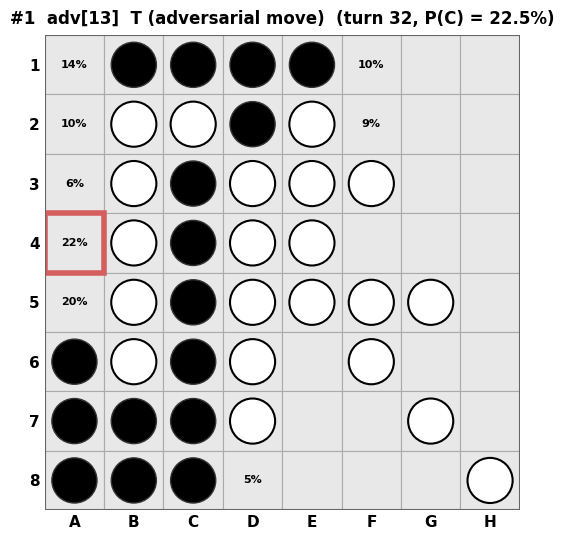


=== #2  adv[4]: C=37 at (4, 5)   P_L=0.104  P_I=0.214  retention=2.05
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv2_moment1.png


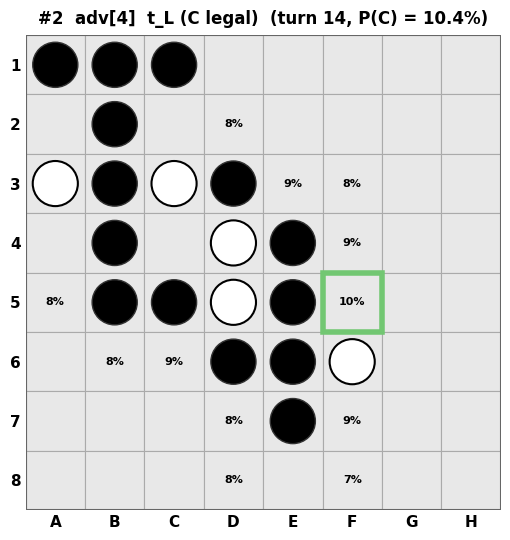

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv2_moment2.png


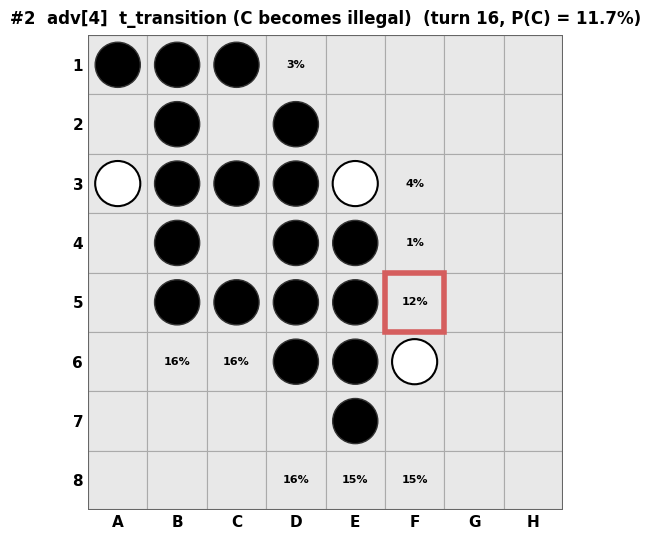

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv2_moment3.png


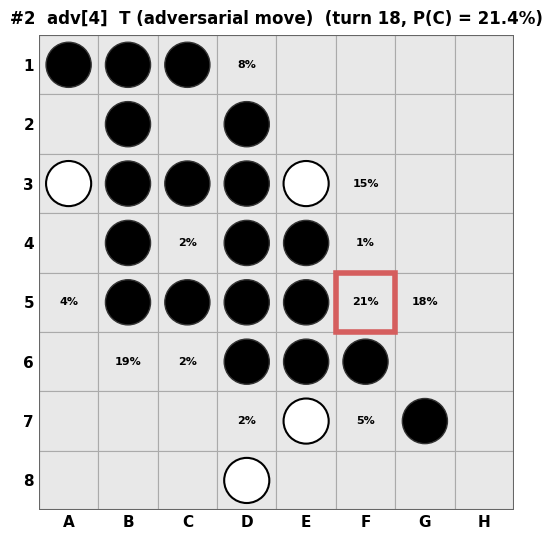


=== #3  adv[271]: C=42 at (5, 2)   P_L=0.100  P_I=0.207  retention=2.08
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv3_moment1.png


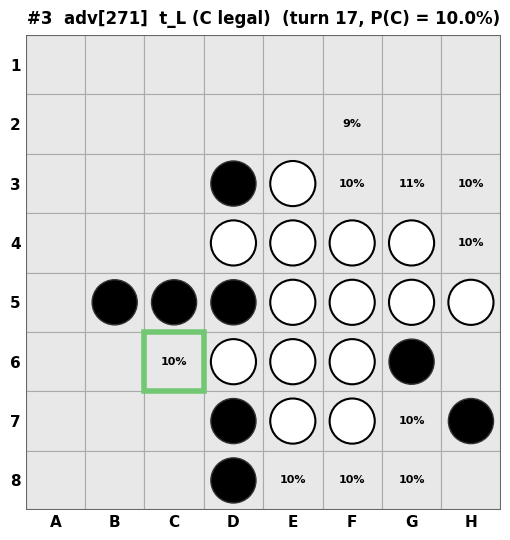

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv3_moment2.png


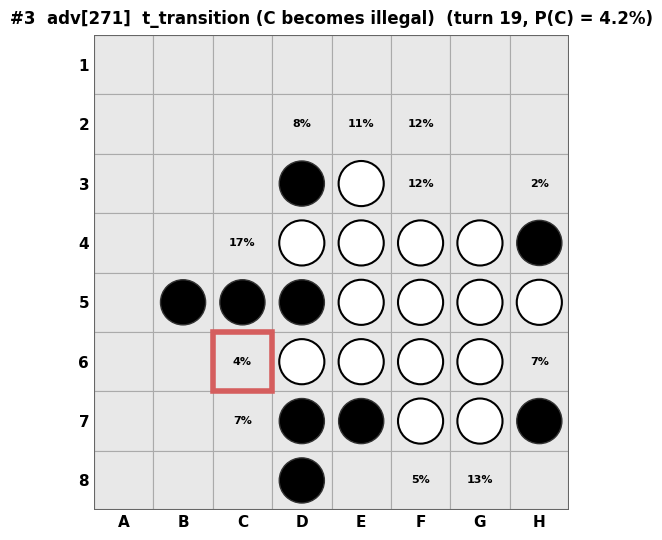

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv3_moment3.png


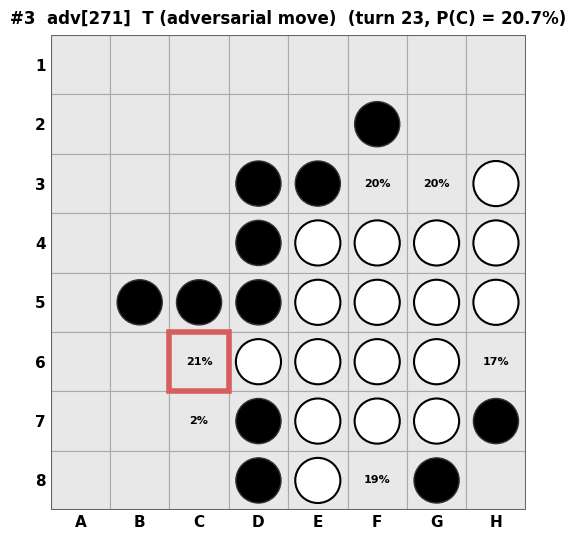


=== #4  adv[146]: C=44 at (5, 4)   P_L=0.201  P_I=0.283  retention=1.41
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv4_moment1.png


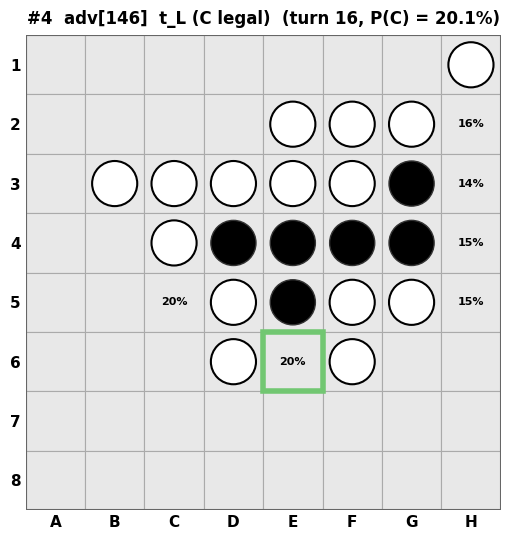

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv4_moment2.png


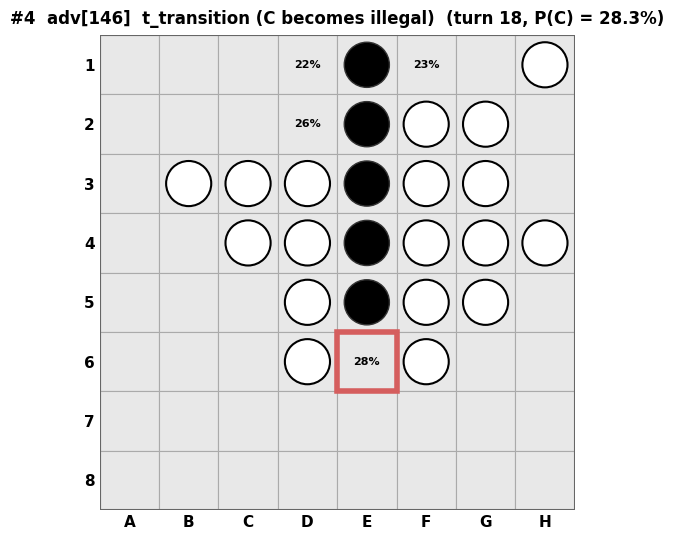

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv4_moment3.png


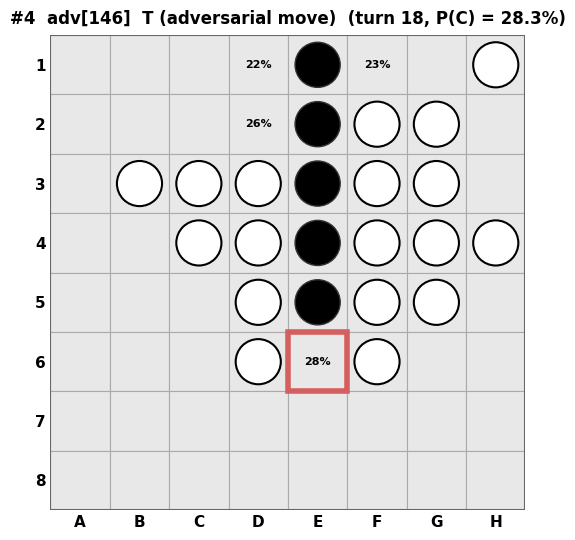


=== #5  adv[2]: C=37 at (4, 5)   P_L=0.104  P_I=0.200  retention=1.92
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv5_moment1.png


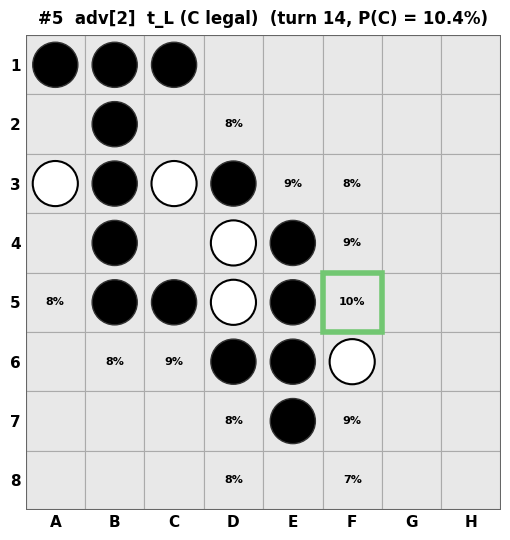

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv5_moment2.png


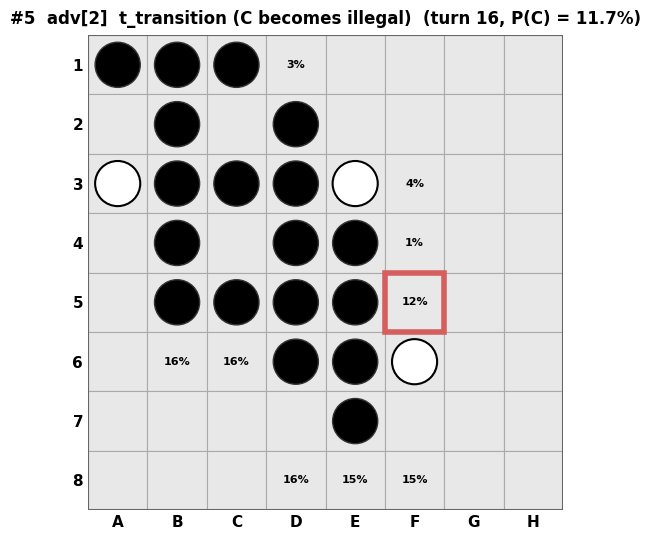

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv5_moment3.png


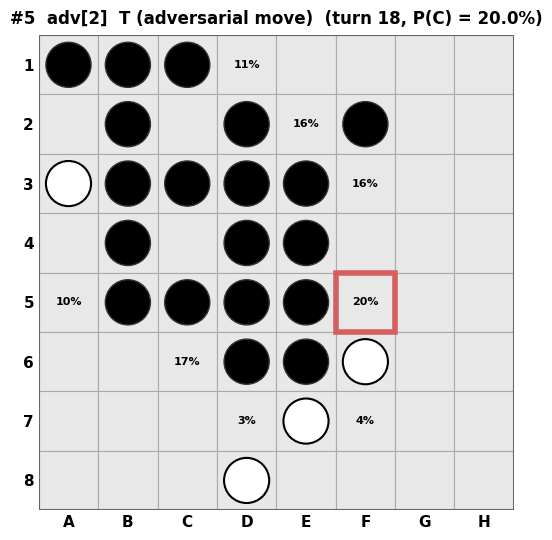

In [46]:
# Section 3a — top-5 adversarial triptychs.
# For each ADV_GAMES[k]: 3 boards at (t_L, t_transition, T).
# States are replayed locally from the hardcoded game.
# Probs come from perf['top_probs'][k, moment].
moment_names = ['t_L (C legal)', 't_transition (C becomes illegal)',
                 'T (adversarial move)']
moment_keys = ['t_L', 't_transition', 'T']

for k, entry in enumerate(ADV_GAMES):
    Cr, Cc = entry['C'] // 8, entry['C'] % 8
    print(f'\n=== {entry["label"]}: C={entry["C"]} at ({Cr}, {Cc})   '
           f'P_L={entry["P_L"]:.3f}  P_I={entry["P_I"]:.3f}  '
           f'retention={entry["P_I"] / max(entry["P_L"], 1e-6):.2f}')
    for m, (name, key) in enumerate(zip(moment_names, moment_keys)):
        t = entry[key]
        state = state_after_replay(entry['game'], t)
        probs = perf['top_probs'][k, m]
        # Legality: is C in valid moves after replaying game[:t+1]?
        board = OthelloBoardState()
        for mv in entry['game'][:t + 1]:
            board.umpire(int(mv))
        legal = entry['C'] in set(board.get_valid_moves())
        p_at_C = float(probs[Cr, Cc])
        title = (f'{entry["label"]}  {name}  '
                 f'(turn {t}, P(C) = {100*p_at_C:.1f}%)')
        render_probs_board(state, probs,
                            focus_cell=(Cr, Cc), legal=legal,
                            out_name=f'adv{k+1}_moment{m+1}.png',
                            title=title)

In [ ]:
# Section 3b — no-flanker figures.
# (1) The single winning position: opp line of length 6 toward the target
#     cell, no valid flanker, model still assigns P ~ 99.85%.
# (2) The MONOTONIC line-growth sequence from a game where the opp-line
#     toward a specific target grows over same-parity turns while the
#     target is always empty AND has no valid flanker (illegal throughout).

# (1) Winning single position (best score across all games)
Tr_flank, Tc_flank = int(perf['flank_target_cell'][0]), int(perf['flank_target_cell'][1])
render_probs_board(
    perf['flank_state'], perf['flank_probs'],
    focus_cell=(Tr_flank, Tc_flank), legal=False,
    out_name='noflank_winning.png',
    title=(f'No-flanker winning example  '
            f'(line length {int(perf["flank_line_len"])}, '
            f'P(target) = {100*float(perf["flank_p_target"]):.1f}%)'))

# (2) Monotonic growth sequence: uses growth_target_cell (may be from a
#     different game than the single winner above).
if perf['growth_states'].shape[0] == 0:
    print('No monotonic growth game found; rerun prep with --growth-* args.')
else:
    Gr, Gc = int(perf['growth_target_cell'][0]), int(perf['growth_target_cell'][1])
    Gd = tuple(int(x) for x in perf['growth_direction'])
    print(f'\nMonotonic growth at target ({Gr}, {Gc}), direction {Gd}:')
    for m in range(perf['growth_states'].shape[0]):
        L = int(perf['growth_line_lens'][m])
        p = float(perf['growth_p_target'][m])
        title = (f'Opp line length {L}  '
                  f'(turn {int(perf["growth_turns"][m])}, '
                  f'P(target) = {100*p:.1f}%)')
        render_probs_board(
            perf['growth_states'][m], perf['growth_probs'][m],
            focus_cell=(Gr, Gc), legal=False,
            out_name=f'noflank_growth_len{L}.png',
            title=title)

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top1.png


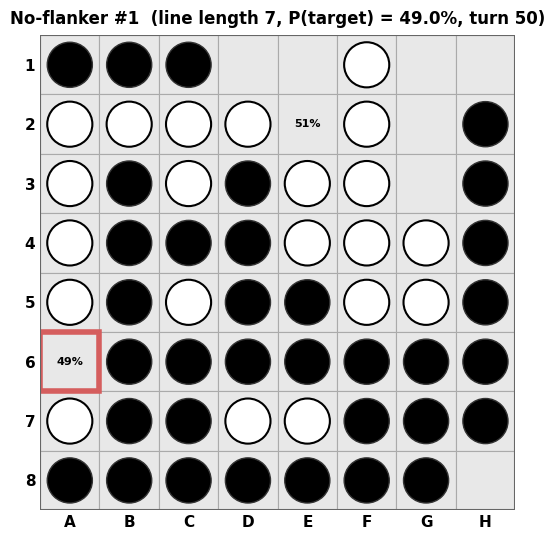

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top2.png


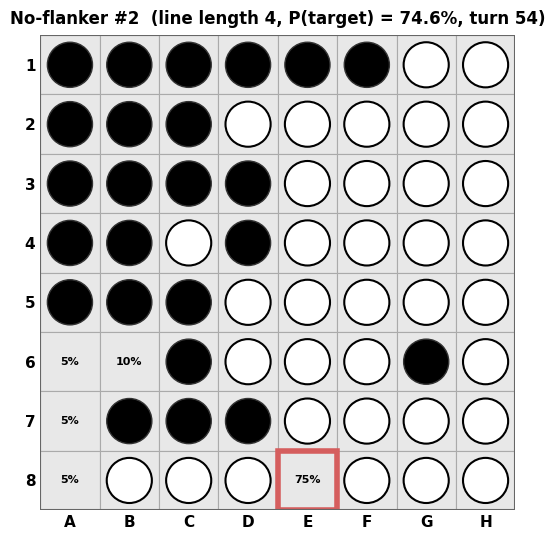

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top3.png


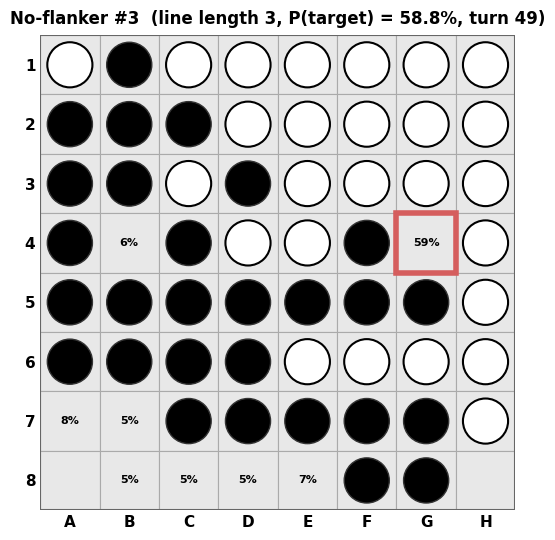

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top4.png


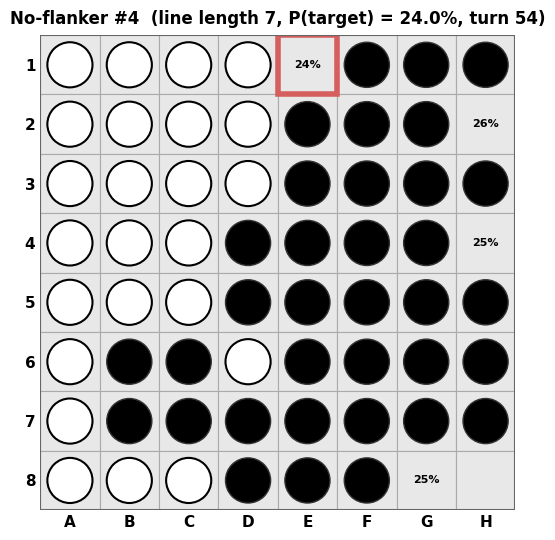

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top5.png


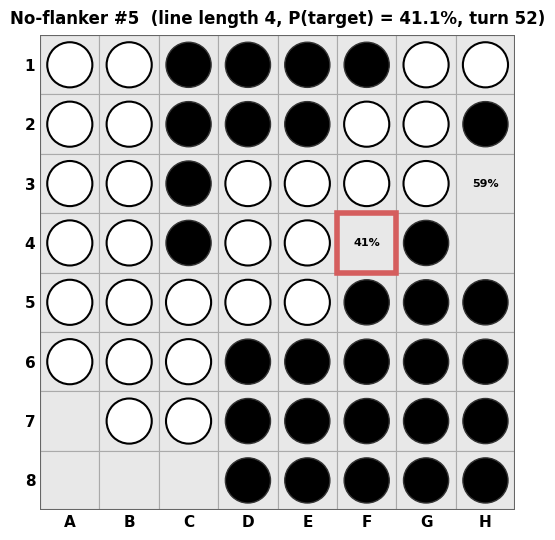

In [48]:
# Section 3c — top-K no-flanker examples across many games.
# Each panel is a distinct game/position where the model puts high prob
# on an illegal cell that has a long opp line but no valid flanker.
if 'top_flank_states' in perf.files:
    for k in range(perf['top_flank_states'].shape[0]):
        tr, tc = int(perf['top_flank_target_cells'][k, 0]), \
                  int(perf['top_flank_target_cells'][k, 1])
        title = (f'No-flanker #{k+1}  '
                  f'(line length {int(perf["top_flank_line_lens"][k])}, '
                  f'P(target) = {100*float(perf["top_flank_p"][k]):.1f}%, '
                  f'turn {int(perf["top_flank_turns"][k])})')
        render_probs_board(
            perf['top_flank_states'][k], perf['top_flank_probs'][k],
            focus_cell=(tr, tc), legal=False,
            out_name=f'noflank_top{k+1}.png',
            title=title)
else:
    print('top_flank_* not in npz — rerun prep_performance_data.py to '
           'populate the top-K no-flanker examples')